# Airbnb Price Prediction Modeling

This notebook is used for training ML models to predict Airbnb listing price. The target variable is `log_price`, and `price`, `log_price`, and `id` are excluded from the model features to avoid target leakage.

In [49]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Data Preparation

In [3]:
DATA_PATH = Path("../data/processed/clean_listings.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (37422, 22)


,id,price,log_price,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,amenities_count
0,2708,67.22,4.222738,1.0,Hollywood,34.09625,-118.34605,Private room in rental unit,Private room,1,1.0,NaN,1.0,30.0,1125.0,301,47,4.87,4.94,4.96,4.87,77
1,2732,213.56,5.368589,0.0,Santa Monica,34.00440,-118.48095,Private room in rental unit,Private room,1,1.0,NaN,1.0,1.0,27.0,350,24,4.41,4.58,4.91,4.22,19
2,6033,99.63,4.611450,0.0,Woodland Hills,34.16887,-118.64478,Entire bungalow,Entire home/apt,3,1.0,1.0,NaN,30.0,1125.0,270,19,4.38,4.00,4.65,4.29,32
3,6931,95.21,4.566533,1.0,Hollywood,34.09626,-118.34372,Private room in rental unit,Private room,1,1.0,NaN,1.0,30.0,1125.0,259,39,4.86,4.92,4.69,4.75,72
4,7874,113.00,4.736198,0.0,Bellflower,33.87687,-118.11444,Private room in home,Private room,2,1.5,NaN,1.0,1.0,730.0,103,26,4.77,4.88,4.77,4.77,22


In [4]:
target_column = "log_price"
excluded_from_features = ["id", "price", "log_price"]

X = df.drop(columns=excluded_from_features)
y = df[target_column]

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (37422, 19)
Y shape: (37422,)


In [10]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'amenities_count']

Categorical features: ['neighbourhood_cleansed', 'property_type', 'room_type']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (29937, 19)
Test shape: (7485, 19)


In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [17]:
def evaluate_model(name, model, X_test, y_test):
    log_preds = model.predict(X_test)

    # Convert log preds back to orginal scale
    y_test_dollars = np.expm1(y_test)
    preds_dollars = np.expm1(log_preds)
    preds_dollars = np.maximum(preds_dollars, 0)

    log_rmse = np.sqrt(mean_squared_error(y_test, log_preds))
    dollar_mae = mean_absolute_error(y_test_dollars, preds_dollars)
    dollar_rmse = np.sqrt(mean_squared_error(y_test_dollars, preds_dollars))
    r2 = r2_score(y_test, log_preds)

    return {
        "model": name, 
        "log_rmse": log_rmse,
        "dollar_mae": dollar_mae,
        "dollar_rmse": dollar_rmse,
        "r2_log_price": r2,
    }

## Baseline Model

In [43]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline_model.fit(X_train, y_train)

results = []
results.append(evaluate_model("Baseline Median:", baseline_model, X_test, y_test))

pd.DataFrame(results)

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
0,Baseline Median:,0.873432,213.835651,385.089072,-7.717540e-07


## Linear Regression

In [44]:
# Linear Regression
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

results.append(evaluate_model("Linear Regression", linear_model, X_test, y_test))

pd.DataFrame(results)

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
0,Baseline Median:,0.873432,213.835651,385.089072,-7.717540e-07
1,Linear Regression,0.402806,109.668703,229.961961,7.873168e-01


## Ridge Regression

In [38]:
# Ridge Regression
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

results.append(evaluate_model("Ridge Regression", ridge_model, X_test, y_test))

pd.DataFrame(results)

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
0,Baseline Median:,0.873432,213.835651,385.089072,-7.717540e-07
1,Linear Regression,0.402806,109.668703,229.961961,7.873168e-01
2,Ridge Regression,0.402065,109.566215,230.130041,7.880983e-01


In [45]:
# Ridge alpha comparison
ridge_alphas = [0.1, 1.0, 10.0, 100.0]

for alpha in ridge_alphas:
    ridge_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", Ridge(alpha=alpha))
        ]
    )

    ridge_model.fit(X_train, y_train)
    results.append(evaluate_model(f"Ridge (Alpha={alpha})", ridge_model, X_test, y_test))

pd.DataFrame(results).sort_values("log_rmse")

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
3,Ridge (Alpha=1.0),0.402065,109.566215,230.130041,7.880983e-01
4,Ridge (Alpha=10.0),0.402104,109.541825,231.146139,7.880576e-01
2,Ridge (Alpha=0.1),0.402781,109.654311,229.941602,7.873428e-01
1,Linear Regression,0.402806,109.668703,229.961961,7.873168e-01
5,Ridge (Alpha=100.0),0.408906,111.059926,235.544867,7.808257e-01
0,Baseline Median:,0.873432,213.835651,385.089072,-7.717540e-07


**Ridge Regression:** Ridge with `alpha=1.0` was the strongest linear model, achieving a log RMSE of 0.402, a dollar MAE of about $109.57, and an R² of 0.788. It slightly improved on ordinary linear regression, showing that modest regularization helped stabilize the model without over-shrinking its coefficients.

## Random Forest

In [46]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100, 
            random_state=42,
            min_samples_leaf=5,
            max_depth=20,
            n_jobs=-1
        )),
    ]
)

random_forest_model.fit(X_train, y_train)

results.append(evaluate_model("Random Forest", random_forest_model, X_test, y_test))

pd.DataFrame(results).sort_values("log_rmse")

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
6,Random Forest,0.350174,94.089006,197.892375,8.392648e-01
3,Ridge (Alpha=1.0),0.402065,109.566215,230.130041,7.880983e-01
4,Ridge (Alpha=10.0),0.402104,109.541825,231.146139,7.880576e-01
2,Ridge (Alpha=0.1),0.402781,109.654311,229.941602,7.873428e-01
1,Linear Regression,0.402806,109.668703,229.961961,7.873168e-01
5,Ridge (Alpha=100.0),0.408906,111.059926,235.544867,7.808257e-01
0,Baseline Median:,0.873432,213.835651,385.089072,-7.717540e-07


## Hist Gradient Boosting

In [51]:
dense_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

dense_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", dense_categorical_transformer, categorical_features),
    ]
)

In [52]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        )),
    ]
)

gradient_boosting_model.fit(X_train, y_train)

results.append(evaluate_model("Hist Gradient Boosting", gradient_boosting_model, X_test, y_test))

pd.DataFrame(results).sort_values("log_rmse")

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
7,Hist Gradient Boosting,0.336277,91.367438,190.685782,8.517699e-01
6,Random Forest,0.350174,94.089006,197.892375,8.392648e-01
3,Ridge (Alpha=1.0),0.402065,109.566215,230.130041,7.880983e-01
4,Ridge (Alpha=10.0),0.402104,109.541825,231.146139,7.880576e-01
2,Ridge (Alpha=0.1),0.402781,109.654311,229.941602,7.873428e-01
1,Linear Regression,0.402806,109.668703,229.961961,7.873168e-01
5,Ridge (Alpha=100.0),0.408906,111.059926,235.544867,7.808257e-01
0,Baseline Median:,0.873432,213.835651,385.089072,-7.717540e-07


In [53]:
results_df = pd.DataFrame(results).sort_values("log_rmse")

results_df.round({
    "log_rmse": 3,
    "dollar_mae": 2,
    "dollar_rmse": 2,
    "r2_log_price": 3
})

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
7,Hist Gradient Boosting,0.336,91.37,190.69,0.852
6,Random Forest,0.350,94.09,197.89,0.839
3,Ridge (Alpha=1.0),0.402,109.57,230.13,0.788
4,Ridge (Alpha=10.0),0.402,109.54,231.15,0.788
2,Ridge (Alpha=0.1),0.403,109.65,229.94,0.787
1,Linear Regression,0.403,109.67,229.96,0.787
5,Ridge (Alpha=100.0),0.409,111.06,235.54,0.781
0,Baseline Median:,0.873,213.84,385.09,-0.000


## Model Comparison

Hist Gradient Boosting performed best overall. It achieved the lowest log RMSE, lowest dollar MAE, lowest dollar RMSE, and highest R² on log price. This suggests that Airbnb prices depend on nonlinear relationships and feature interactions, such as the combination of neighborhood, room type, bedrooms, bathrooms, and amenities.

The baseline median model performed much worse because it predicts the same median price for every listing and does not use any listing features. Linear Regression and Ridge Regression improved substantially over the baseline, but they were outperformed by Random Forest and Hist Gradient Boosting. This shows that nonlinear tree-based models are better suited here

## Model Diagnostics

In [55]:
best_model = gradient_boosting_model

log_preds = best_model.predict(X_test)

y_test_dollars = np.expm1(y_test)
preds_dollars = np.expm1(log_preds)
preds_dollars = np.maximum(preds_dollars, 0)

prediction_df = pd.DataFrame({
    "actual_price": y_test_dollars,
    "predicted_price": preds_dollars,
    "actual_log_price": y_test,
    "predicted_log_price": log_preds,
})

prediction_df["error"] = prediction_df["predicted_price"] - prediction_df["actual_price"]
prediction_df["absolute_error"] = prediction_df["error"].abs()

prediction_df.head()

,actual_price,predicted_price,actual_log_price,predicted_log_price,error,absolute_error
26114,1248.33,1491.348465,7.130363,7.308106,243.018465,243.018465
25357,320.00,266.046576,5.771441,5.587423,-53.953424,53.953424
15159,259.95,273.098145,5.564329,5.613486,13.148145,13.148145
32460,341.79,403.243014,5.837118,6.002016,61.453014,61.453014
4285,159.93,213.548345,5.080969,5.368535,53.618345,53.618345


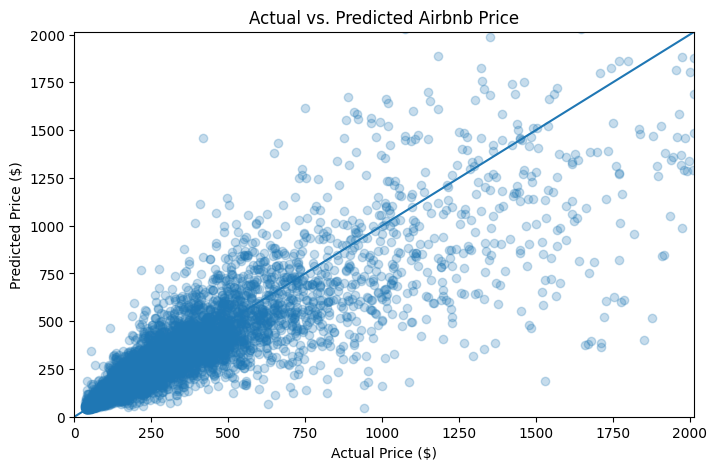

In [58]:
plt.figure(figsize=(8, 5))

limit = prediction_df[["actual_price", "predicted_price"]].quantile(0.99).max()

plt.scatter(
    prediction_df["actual_price"],
    prediction_df["predicted_price"],
    alpha=0.25
)

plt.plot([0, limit], [0, limit])
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted Airbnb Price")
plt.show()

The actual vs. predicted plot shows that the model captures the overall pricing trend, since many points follow the diagonal line. Predictions are most accurate for lower and mid-priced listings, where most of the data is concentrated. The model has more error for expensive listings, most likely because high-priced Airbnbs may depend on features not fully captured in the dataset.

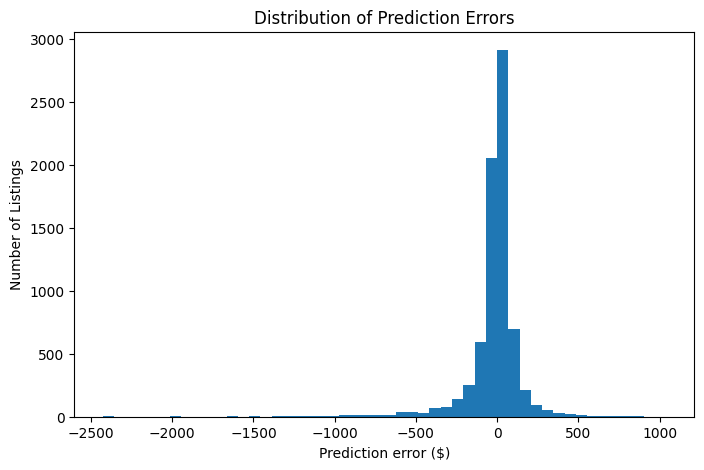

In [59]:
plt.figure(figsize=(8, 5))
plt.hist(prediction_df["error"], bins=50)
plt.xlabel("Prediction error ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Prediction Errors")
plt.show()

The prediction errors are centered close to zero, which suggests the model is not strongly overpredicting or underpredicting most listings overall. Most errors are relatively small, but the distribution has a longer left tail, meaning there are some listings where the model underpredicted the true price by a large amount. 

In [60]:
worst_predictions = prediction_df.sort_values("absolute_error", ascending=False).head(10)

worst_predictions

,actual_price,predicted_price,actual_log_price,predicted_log_price,error,absolute_error
2725,2500.50,71.402151,7.824646,4.282236,-2429.097849,2429.097849
1900,2774.67,400.026089,7.928647,5.994026,-2374.643911,2374.643911
23873,2871.97,561.571948,7.963102,6.332519,-2310.398052,2310.398052
7718,2562.67,575.094601,7.849195,6.356272,-1987.575399,1987.575399
10644,2212.37,262.680287,7.702272,5.574737,-1949.689713,1949.689713
24482,2841.90,1094.645564,7.952580,6.999099,-1747.254436,1747.254436
14702,2225.50,519.264048,7.708186,6.254336,-1706.235952,1706.235952
27393,2396.67,737.122331,7.782253,6.604110,-1659.547669,1659.547669
6161,2684.00,1027.112928,7.895436,6.935480,-1656.887072,1656.887072
11488,2057.00,401.245690,7.629490,5.997063,-1655.754310,1655.754310


In [61]:
worst_with_features = X_test.loc[worst_predictions.index].copy()

worst_with_features["actual_price"] = worst_predictions["actual_price"]
worst_with_features["predicted_price"] = worst_predictions["predicted_price"]
worst_with_features["absolute_error"] = worst_predictions["absolute_error"]

worst_with_features[
    [
        "neighbourhood_cleansed",
        "property_type",
        "room_type",
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "actual_price",
        "predicted_price",
        "absolute_error"
    ]
].head(10)

,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,actual_price,predicted_price,absolute_error
2725,Alhambra,Private room in home,Private room,2,1.0,2.0,2.0,2500.50,71.402151,2429.097849
1900,Los Feliz,Entire home,Entire home/apt,4,3.0,2.0,2.0,2774.67,400.026089,2374.643911
23873,Hollywood Hills West,Entire home,Entire home/apt,4,3.0,2.0,2.0,2871.97,561.571948,2310.398052
7718,Silver Lake,Entire home,Entire home/apt,6,3.5,3.0,3.0,2562.67,575.094601,1987.575399
10644,Gramercy Park,Entire home,Entire home/apt,6,2.0,2.0,2.0,2212.37,262.680287,1949.689713
24482,Hollywood Hills West,Entire home,Entire home/apt,8,4.0,4.0,4.0,2841.90,1094.645564,1747.254436
14702,Glassell Park,Entire home,Entire home/apt,6,2.0,3.0,4.0,2225.50,519.264048,1706.235952
27393,Tarzana,Entire home,Entire home/apt,6,3.0,4.0,4.0,2396.67,737.122331,1659.547669
6161,Bel-Air,Entire villa,Entire home/apt,10,4.0,5.0,5.0,2684.00,1027.112928,1656.887072
11488,Beverly Hills,Private room in home,Private room,2,6.5,6.0,4.0,2057.00,401.245690,1655.754310


The worst prediction cases are mostly high-priced or unusual listings. Many of these listings have actual nightly prices above $2,000, but the model predicts much lower prices. This suggests that the model struggles most with luxury or outlier listings, where price may depend on details not fully captured in the dataset, such as views, interior quality, special amenities, or exact location. This also explains why the model performs better on typical lower and mid-priced listings than on very expensive listings.

These errors are not surprising because the model only uses structured listing features and does not include more detailed information like listing descriptions, images, or detailed amenity quality.

Note: Only a subset of the features are used for the worst predictions to make the error analysis easier to read. The model still used all features during training, but this table focuses on the most interpretable listing attributes, such as location, room type, property type, bedrooms, bathrooms, and guest capacity.

## Feature Importance

In [64]:
from sklearn.inspection import permutation_importance

best_model = gradient_boosting_model

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
10,minimum_nights,0.255902,0.001936
6,accommodates,0.217648,0.004880
3,longitude,0.093552,0.002945
5,room_type,0.066813,0.002272
7,bathrooms,0.060476,0.002177
2,latitude,0.053359,0.000775
8,bedrooms,0.032406,0.001280
4,property_type,0.025156,0.001443
12,availability_365,0.022474,0.001098
1,neighbourhood_cleansed,0.019169,0.000669


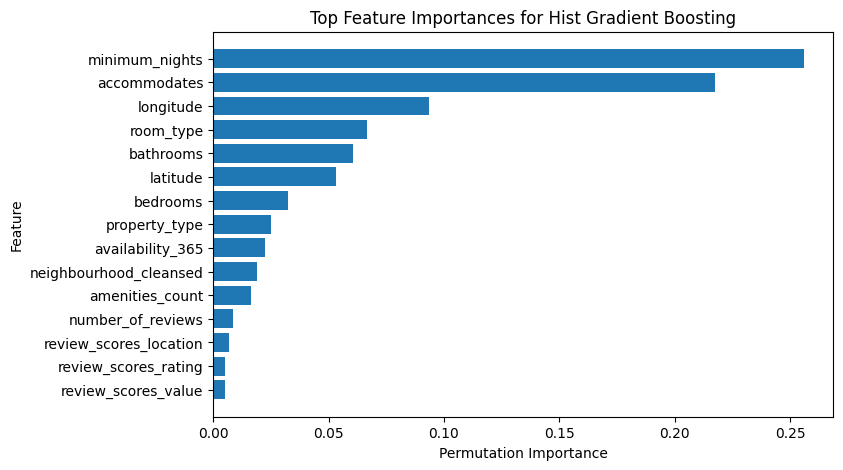

In [69]:
top_importance = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances for Hist Gradient Boosting")
plt.show()

The permutation importance results show that `minimum_nights`, `accommodates`, `longitude`, and `latitude` were the most important predictors. This suggests that Airbnb price depends heavily on booking rules, listing size, and location. Room type, bathrooms, and bedrooms also mattered, which makes sense because larger or entire-home listings usually cost more. 

## Save Best Model and Results

In [ ]:
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = gradient_boosting_model

joblib.dump(best_model, MODEL_DIR / "best_airbnb_price_model.joblib")

print("Saved best model to:", MODEL_DIR / "best_airbnb_price_model.joblib")

Saved best model to: ../models/best_airbnb_price_model.joblib


In [71]:
results_df = pd.DataFrame(results).sort_values("log_rmse")

results_df.to_csv("../reports/model_results.csv", index=False)

results_df.round({
    "log_rmse": 3,
    "dollar_mae": 2,
    "dollar_rmse": 2,
    "r2_log_price": 3,

})

,model,log_rmse,dollar_mae,dollar_rmse,r2_log_price
7,Hist Gradient Boosting,0.336,91.37,190.69,0.852
6,Random Forest,0.350,94.09,197.89,0.839
3,Ridge (Alpha=1.0),0.402,109.57,230.13,0.788
4,Ridge (Alpha=10.0),0.402,109.54,231.15,0.788
2,Ridge (Alpha=0.1),0.403,109.65,229.94,0.787
1,Linear Regression,0.403,109.67,229.96,0.787
5,Ridge (Alpha=100.0),0.409,111.06,235.54,0.781
0,Baseline Median:,0.873,213.84,385.09,-0.000


In [72]:
importance_df.to_csv("../reports/feature_importance.csv", index=False)

importance_df.head(15)

,feature,importance_mean,importance_std
10,minimum_nights,0.255902,0.001936
6,accommodates,0.217648,0.004880
3,longitude,0.093552,0.002945
5,room_type,0.066813,0.002272
7,bathrooms,0.060476,0.002177
2,latitude,0.053359,0.000775
8,bedrooms,0.032406,0.001280
4,property_type,0.025156,0.001443
12,availability_365,0.022474,0.001098
1,neighbourhood_cleansed,0.019169,0.000669


In [75]:
loaded_model = joblib.load("../models/best_airbnb_price_model.joblib")

sample_predictions = loaded_model.predict(X_test.head())

np.expm1(sample_predictions)

array([1491.34846506,  266.04657555,  273.09814463,  403.24301374,
        213.54834544])